<a href="https://colab.research.google.com/github/sarikahussain67-commits/AI-Electricity-Demand-Forecasting/blob/main/AI_Electricity_Demand_Forecasting_Capstone_Interim_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Electricity Demand Forecasting for AI Data Centers
**QM640 Capstone Project**

Machine Learning-Based Forecasting of Electricity Demand for AI Data Centers.

In [8]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import shap


## Load Dataset

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
file_path = "/content/drive/MyDrive/Dataset_Capstone_Project.csv"
DatasetCaps = pd.read_csv(file_path)

## Dataset Information

In [11]:
DatasetCaps.info()
DatasetCaps.describe()
DatasetCaps.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Year                               120 non-null    int64  
 1   Month                              120 non-null    int64  
 2   Total Electricity_Consumption_TWh  120 non-null    float64
 3   Average Price USD/kWh              120 non-null    float64
 4   AI_Investment_USD_Billion          120 non-null    float64
 5   Renewable_Energy_Share_%           120 non-null    float64
dtypes: float64(4), int64(2)
memory usage: 5.8 KB


(120, 6)

## Missing Values

In [12]:
DatasetCaps.isnull().sum()

,0
Year,0
Month,0
Total Electricity_Consumption_TWh,0
Average Price USD/kWh,0
AI_Investment_USD_Billion,0
Renewable_Energy_Share_%,0


## Duplicate Records

In [13]:
DatasetCaps.duplicated().sum()

np.int64(0)

## Data Cleaning

In [14]:
DatasetCaps['Date'] = pd.to_datetime(DatasetCaps['Year'].astype(str) + '-' + DatasetCaps['Month'].astype(str) + '-01')
DatasetCaps = DatasetCaps.sort_values('Date')
DatasetCaps.fillna(method='ffill', inplace=True)

## Feature Engineering

In [15]:
DatasetCaps['Year']=DatasetCaps.Date.dt.year
DatasetCaps['Month']=DatasetCaps.Date.dt.month
DatasetCaps['Quarter']=DatasetCaps.Date.dt.quarter
DatasetCaps['Lag1']=DatasetCaps['Total Electricity_Consumption_TWh'].shift(1)
DatasetCaps['Lag3']=DatasetCaps['Total Electricity_Consumption_TWh'].shift(3)
DatasetCaps['RollingMean3']=DatasetCaps['Total Electricity_Consumption_TWh'].rolling(3).mean()
DatasetCaps=DatasetCaps.dropna()

## Exploratory Data Analysis (EDA)

## 1.Electricity Trend

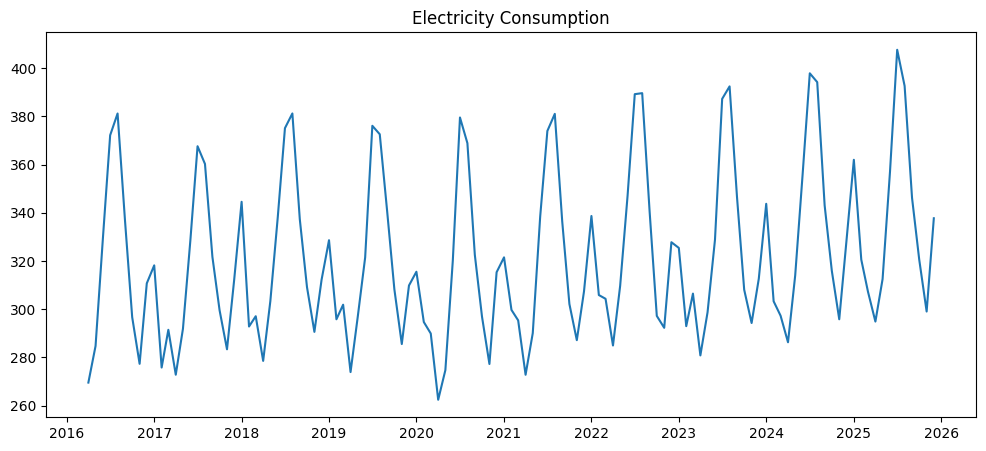

In [16]:
plt.figure(figsize=(12,5))
plt.plot(DatasetCaps['Date'], DatasetCaps['Total Electricity_Consumption_TWh'])
plt.title('Electricity Consumption')
plt.show()

### 2. Distribution of Total Electricity Consumption

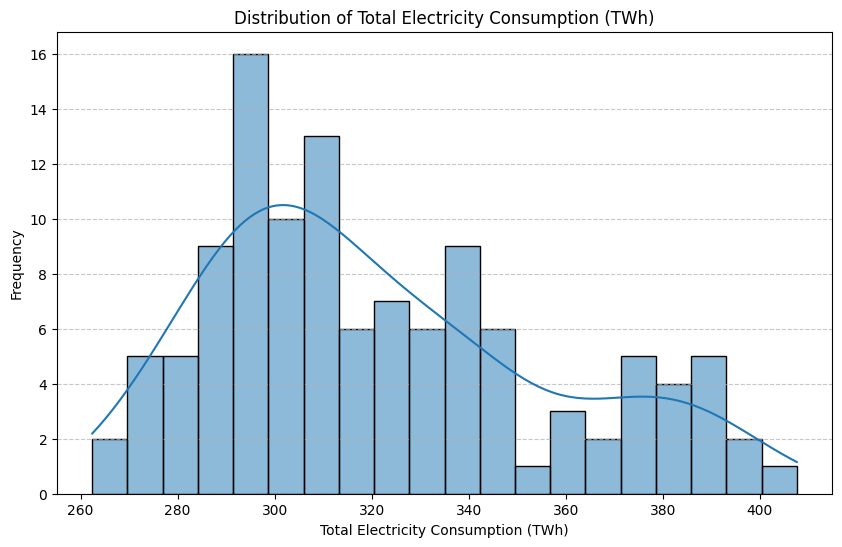

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(DatasetCaps['Total Electricity_Consumption_TWh'], kde=True, bins=20)
plt.title('Distribution of Total Electricity Consumption (TWh)')
plt.xlabel('Total Electricity Consumption (TWh)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 3. Seasonal Decomposition

Seasonal decomposition helps us to break down a time series into its trend, seasonal, and residual components. This can reveal underlying patterns that are not immediately obvious from the raw data.

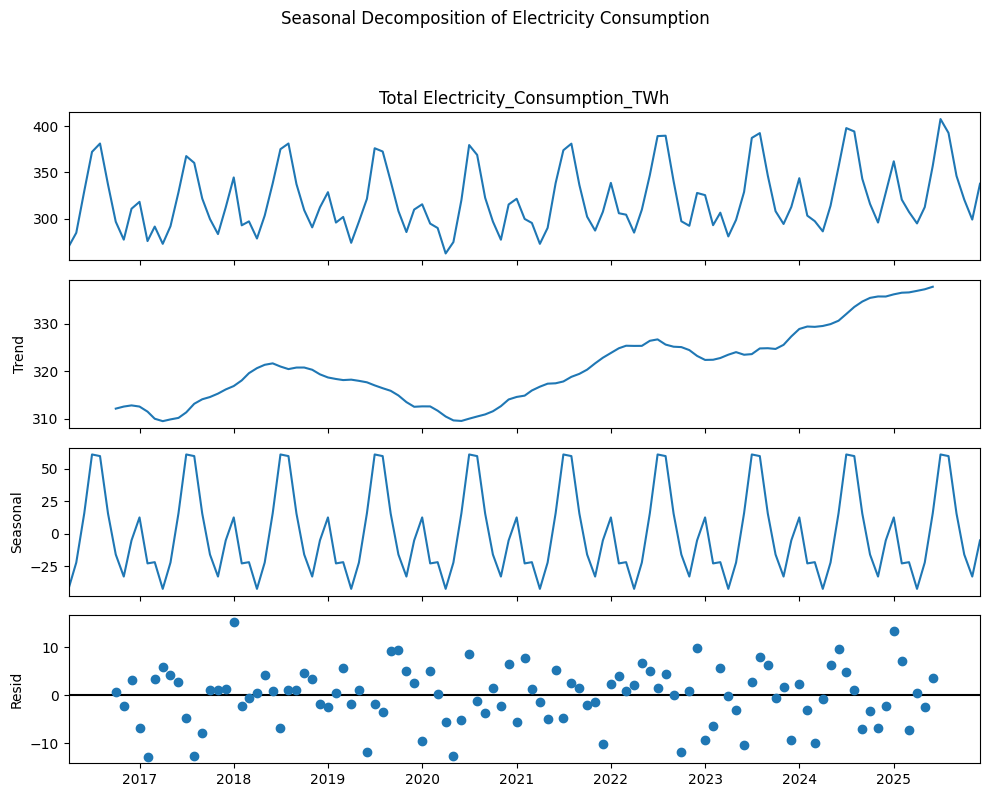

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure the Date column is the index for seasonal decomposition
df_decompose = DatasetCaps.set_index('Date')['Total Electricity_Consumption_TWh']

# Perform seasonal decomposition
# The 'period' parameter should be set according to the frequency of your data.
# For monthly data, a period of 12 (for yearly seasonality) is appropriate.
# adjust the period based on the actual data frequency if it's different.
decomposition = seasonal_decompose(df_decompose, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.suptitle('Seasonal Decomposition of Electricity Consumption', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

### 4. Monthly and Yearly Seasonality Plots

Visualizing the average electricity consumption by month and year can clearly show seasonal patterns and long-term trends.

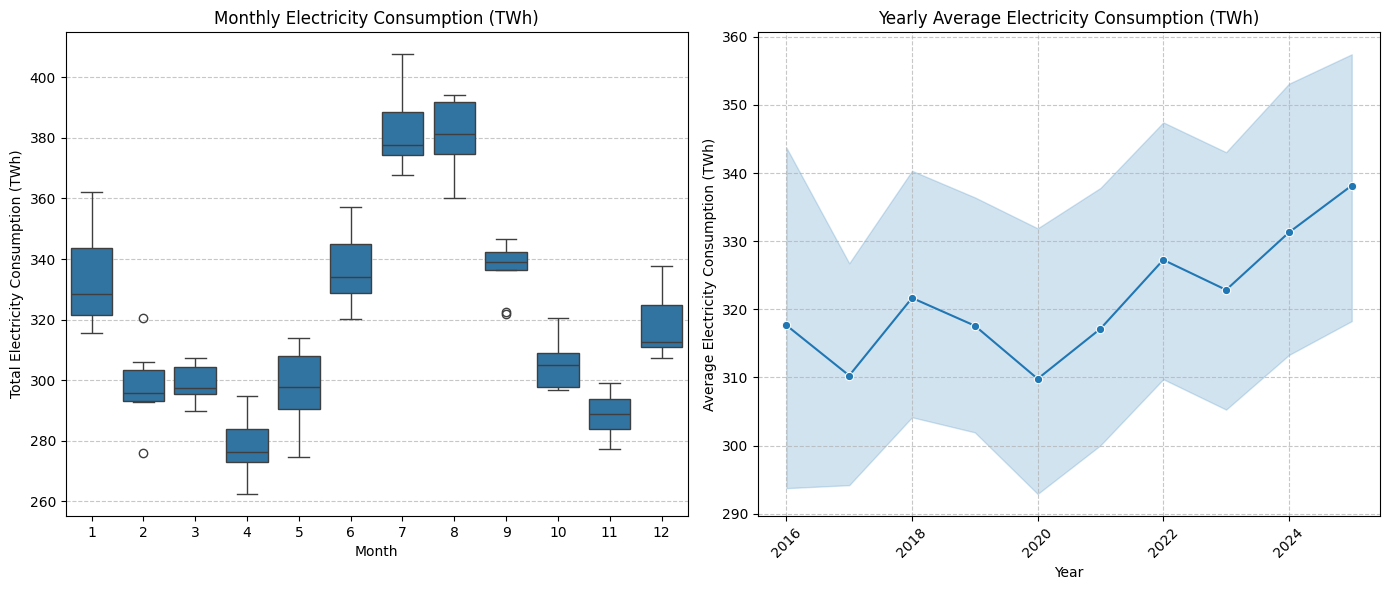

In [19]:
plt.figure(figsize=(14, 6))

# Monthly Seasonality
plt.subplot(1, 2, 1)
sns.boxplot(x='Month', y='Total Electricity_Consumption_TWh', data=DatasetCaps)
plt.title('Monthly Electricity Consumption (TWh)')
plt.xlabel('Month')
plt.ylabel('Total Electricity Consumption (TWh)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Yearly Trend
plt.subplot(1, 2, 2)
sns.lineplot(x='Year', y='Total Electricity_Consumption_TWh', data=DatasetCaps, estimator='mean', marker='o')
plt.title('Yearly Average Electricity Consumption (TWh)')
plt.xlabel('Year')
plt.ylabel('Average Electricity Consumption (TWh)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 5. AI Investment Trend

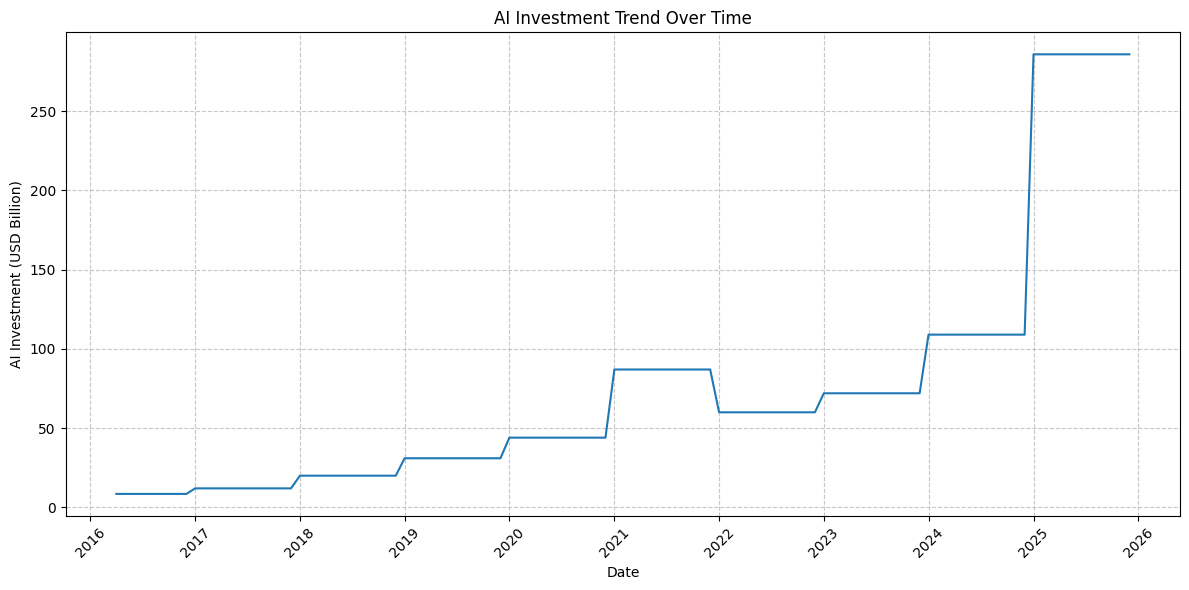

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='AI_Investment_USD_Billion', data=DatasetCaps)
plt.title('AI Investment Trend Over Time')
plt.xlabel('Date')
plt.ylabel('AI Investment (USD Billion)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6. Renewable Energy Share Trend

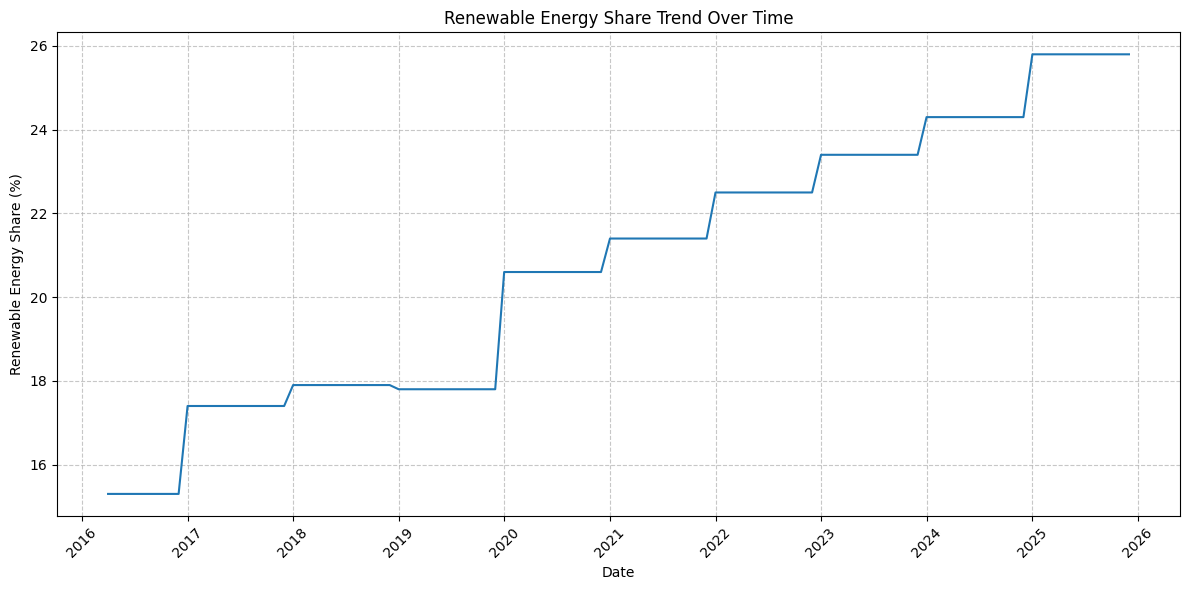

In [21]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Renewable_Energy_Share_%', data=DatasetCaps)
plt.title('Renewable Energy Share Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Renewable Energy Share (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7. Electricity Price Trend

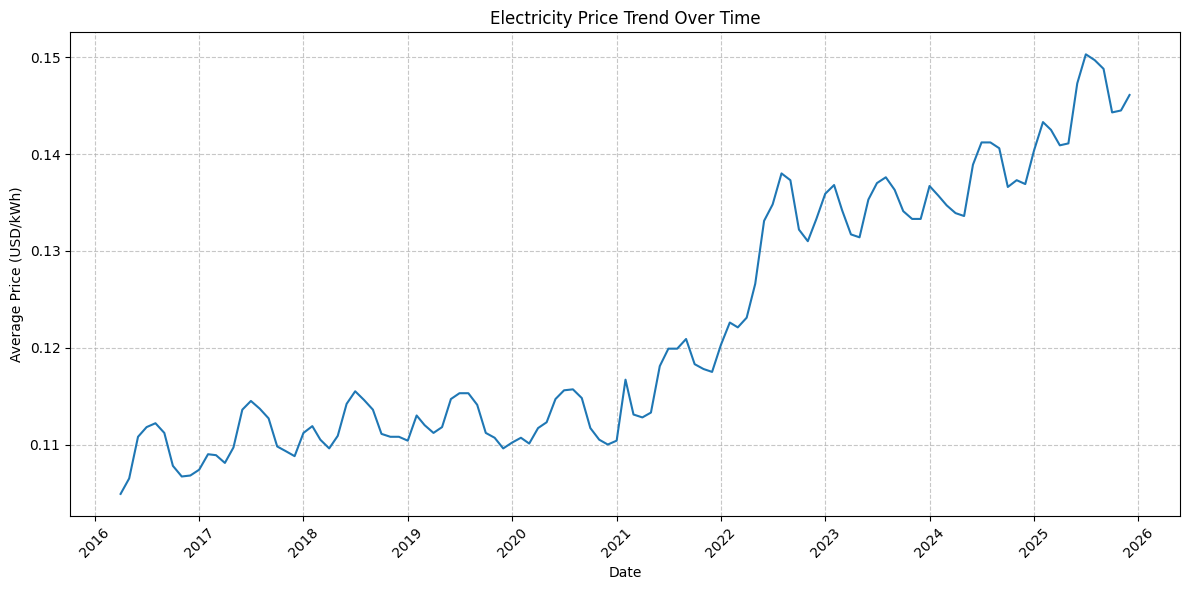

In [22]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Average Price USD/kWh', data=DatasetCaps)
plt.title('Electricity Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price (USD/kWh)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 8. Data Corelation-Relationship between predictors and target variable

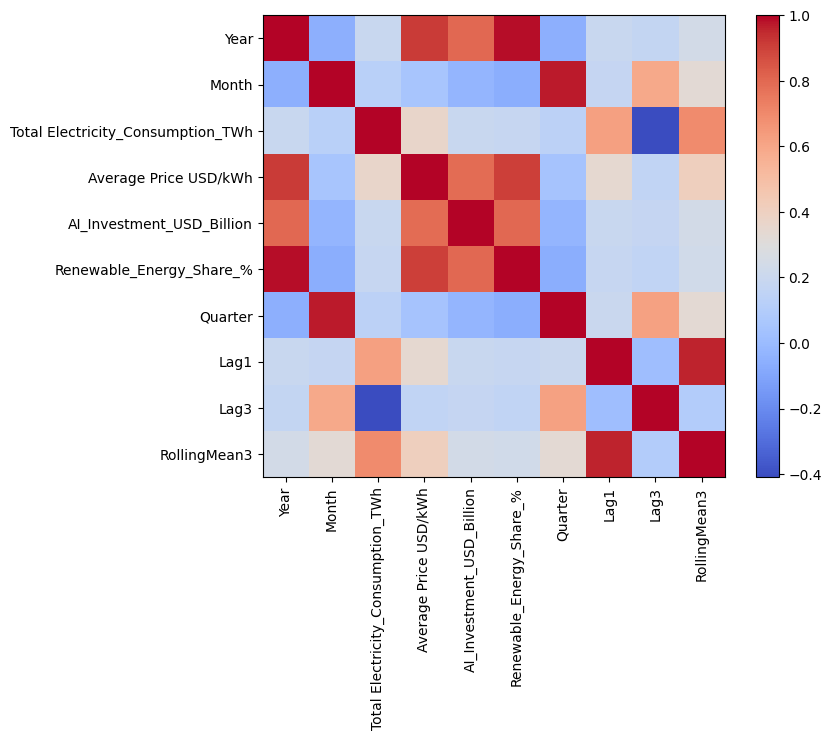

In [ ]:
plt.figure(figsize=(8,6))
plt.imshow(DatasetCaps.corr(numeric_only=True), cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(DatasetCaps.corr(numeric_only=True).columns)), DatasetCaps.corr(numeric_only=True).columns, rotation=90)
plt.yticks(range(len(DatasetCaps.corr(numeric_only=True).columns)), DatasetCaps.corr(numeric_only=True).columns)
plt.show()

### 9. Feature Relationship Analysis (Correlation Matrix)

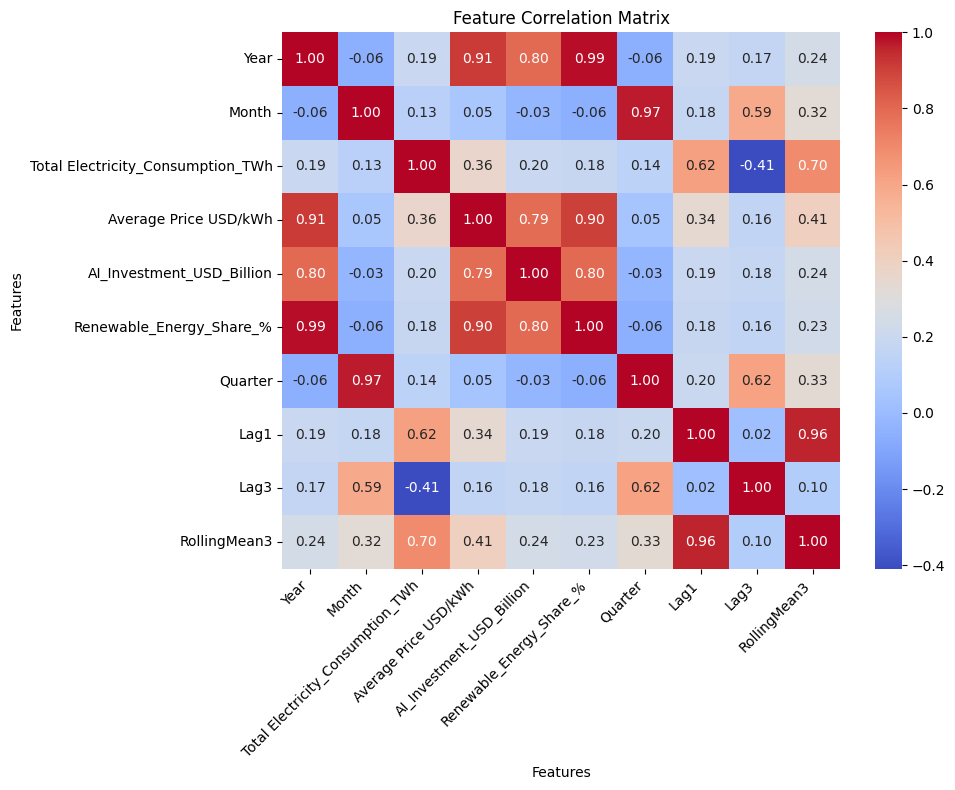

In [24]:
plt.figure(figsize=(10, 8))
sns.heatmap(DatasetCaps.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.xlabel('Features')
plt.ylabel('Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Train Test Split

In [ ]:
train=DatasetCaps.iloc[:84]
validation=DatasetCaps.iloc[84:102]
test=DatasetCaps.iloc[102:]

## Prophet Model

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


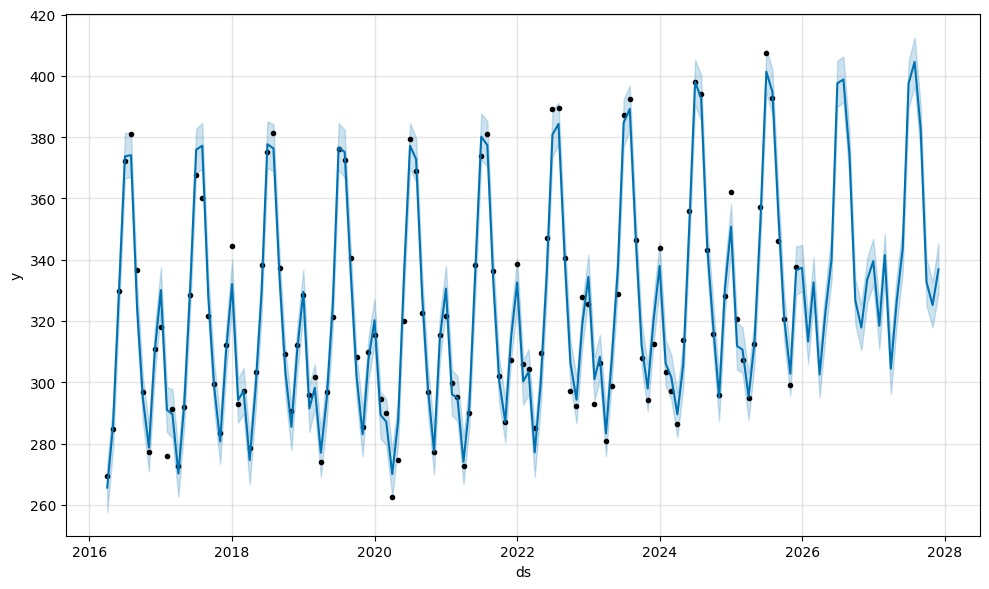

In [ ]:
prophet_df=DatasetCaps[['Date','Total Electricity_Consumption_TWh']].rename(columns={'Date':'ds','Total Electricity_Consumption_TWh':'y'})
model=Prophet(weekly_seasonality=True)
model.fit(prophet_df)
future=model.make_future_dataframe(periods=24,freq='M')
forecast=model.predict(future)
model.plot(forecast);

In [ ]:
# Recalculate evaluation metrics with the new forecast
forecast_test = forecast[forecast['ds'].isin(test['Date'])]

y_true = test['Total Electricity_Consumption_TWh']
y_pred = forecast_test['yhat']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f'Prophet Model (with weekly_seasonality=True) MAE: {mae:.2f}')
print(f'Prophet Model (with weekly_seasonality=True) RMSE: {rmse:.2f}')
print(f'Prophet Model (with weekly_seasonality=True) R2 Score: {r2:.2f}')

Prophet Model (with weekly_seasonality=True) MAE: 3.74
Prophet Model (with weekly_seasonality=True) RMSE: 5.00
Prophet Model (with weekly_seasonality=True) R2 Score: 0.98


## Prophet Model (with weekly_seasonality=True): Actual vs. Predicted

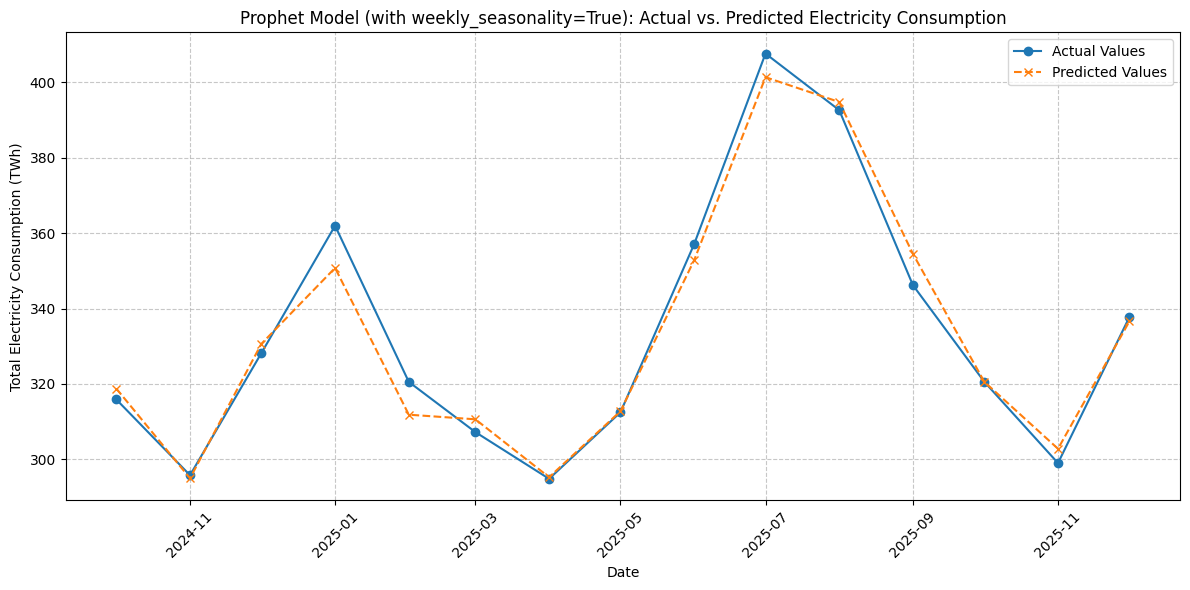

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(forecast_test['ds'], y_true, label='Actual Values', marker='o')
plt.plot(forecast_test['ds'], y_pred, label='Predicted Values', linestyle='--', marker='x')
plt.title('Prophet Model (with weekly_seasonality=True): Actual vs. Predicted Electricity Consumption')
plt.xlabel('Date')
plt.ylabel('Total Electricity Consumption (TWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

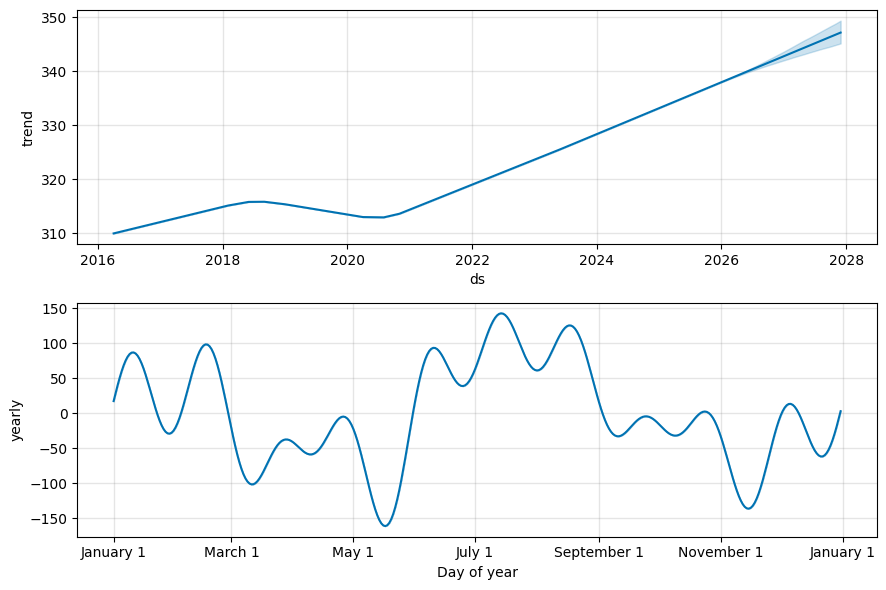

In [ ]:
model.plot_components(forecast);

In [ ]:
# Filter the forecast to match the test set dates
forecast_test = forecast[forecast['ds'].isin(test['Date'])]

# Extract actual values from the test set
y_true = test['Total Electricity_Consumption_TWh']

# Extract predicted values (yhat) from the filtered forecast
y_pred = forecast_test['yhat']

# Calculate evaluation metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f'Prophet Model MAE: {mae:.2f}')
print(f'Prophet Model RMSE: {rmse:.2f}')
print(f'Prophet Model R2 Score: {r2:.2f}')

Prophet Model MAE: 4.13
Prophet Model RMSE: 5.15
Prophet Model R2 Score: 0.98


## Prophet Model: Actual vs. Predicted

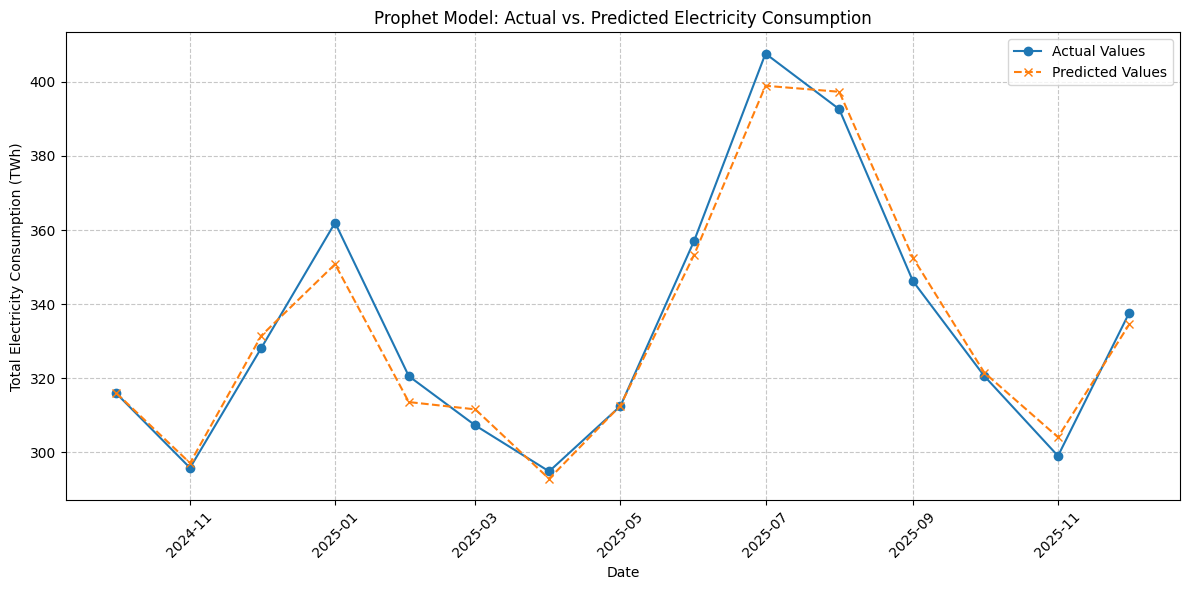

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(forecast_test['ds'], y_true, label='Actual Values', marker='o')
plt.plot(forecast_test['ds'], y_pred, label='Predicted Values', linestyle='--', marker='x')
plt.title('Prophet Model: Actual vs. Predicted Electricity Consumption')
plt.xlabel('Date')
plt.ylabel('Total Electricity Consumption (TWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## XGBoost Model

In [ ]:
features=['AI_Investment_USD_Billion',
'Renewable_Energy_Share_%','Average Price USD/kWh',
'Lag1','Lag3','Month','Quarter','Year']
X=DatasetCaps[features]
y=DatasetCaps['Total Electricity_Consumption_TWh']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=False)
xgb=XGBRegressor()
xgb.fit(X_train,y_train)
pred=xgb.predict(X_test)
print('MAE',mean_absolute_error(y_test,pred))
print('RMSE',np.sqrt(mean_squared_error(y_test,pred)))
print('R2',r2_score(y_test,pred))

MAE 14.654505310058596
RMSE 19.686459857100832
R2 0.6876063316960517


## LSTM Skeleton

In [ ]:
sequence_length = 12

X = []
y = []

for i in range(sequence_length, len(scaled)):

    X.append(scaled[i-sequence_length:i])

    # Target is Electricity Consumption
    y.append(scaled[i,0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(105, 12, 1)
(105,)


In [ ]:
sequence_length = 12

X = []
y = []

for i in range(sequence_length, len(scaled)):

    X.append(scaled[i-sequence_length:i])

    # Target is Electricity Consumption
    y.append(scaled[i,0])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(105, 12, 1)
(105,)


In [ ]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(84, 12, 1)
(21, 12, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(
    LSTM(
        units=64,
        return_sequences=False,
        input_shape=(12,4)
    )
)

model.add(Dropout(0.2))

model.add(Dense(32,activation='relu'))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(

    X_train,
    y_train,

    epochs=100,

    batch_size=8,

    validation_split=0.2,

    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - loss: 0.2086 - val_loss: 0.1254
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0945 - val_loss: 0.0482
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0600 - val_loss: 0.0550
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0621 - val_loss: 0.0465
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0539 - val_loss: 0.0473
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0525 - val_loss: 0.0444
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0497 - val_loss: 0.0440
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0494 - val_loss: 0.0435
Epoch 9/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0512 - val_loss: 0.0449
Epoch 10/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0506 - val_loss: 0.0426
Epoch 11/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0504 - val_loss: 0.0423
Epoch 12/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0502 - val_lo

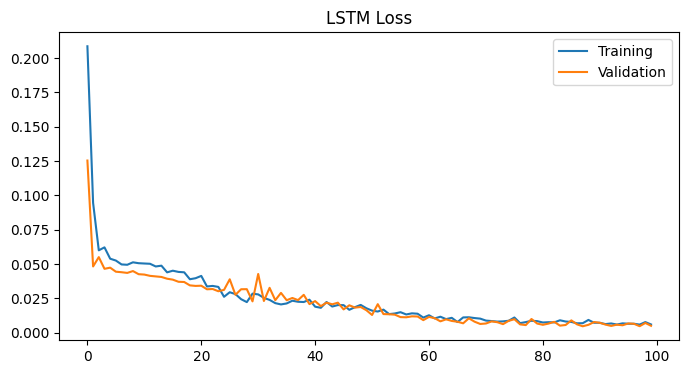

In [ ]:
plt.figure(figsize=(8,4))

plt.plot(history.history['loss'],label='Training')

plt.plot(history.history['val_loss'],label='Validation')

plt.legend()

plt.title("LSTM Loss")

plt.show()

In [ ]:
pred_scaled = model.predict(X_test)

print(pred_scaled.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
(21, 1)


In [ ]:
dummy_pred = np.zeros((len(pred_scaled),4))

dummy_pred[:,0] = pred_scaled[:,0]

prediction = scaler.inverse_transform(dummy_pred)[:,0]

In [ ]:
dummy_actual = np.zeros((len(y_test),4))

dummy_actual[:,0] = y_test

actual = scaler.inverse_transform(dummy_actual)[:,0]

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

MAE = mean_absolute_error(actual,prediction)

RMSE = np.sqrt(
    mean_squared_error(actual,prediction)
)

R2 = r2_score(actual,prediction)

MAPE = np.mean(
    np.abs((actual-prediction)/actual)
)*100

print("MAE :",MAE)

print("RMSE:",RMSE)

print("MAPE:",MAPE)

print("R2 :",R2)

MAE : 16.900688871148834
RMSE: 19.545288919735935
MAPE: 4.999419249729523
R2 : 0.7043033846931144


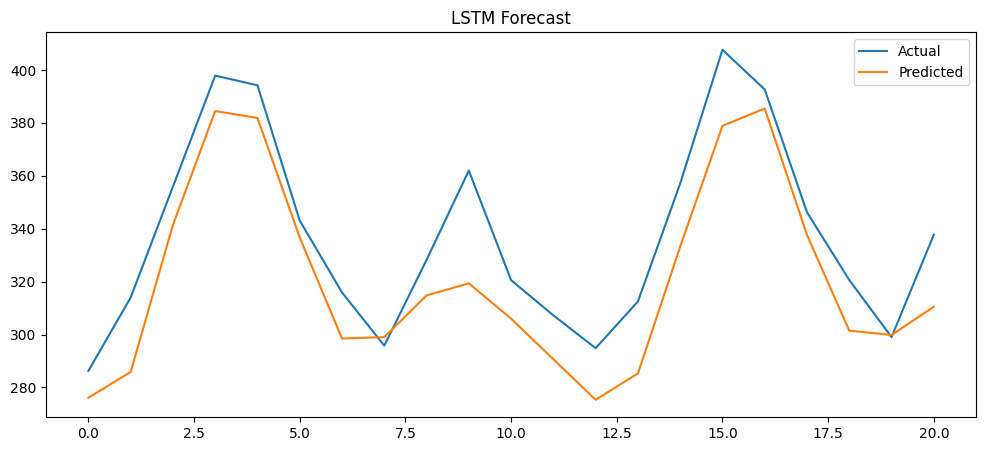

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(actual,label="Actual")

plt.plot(prediction,label="Predicted")

plt.title("LSTM Forecast")

plt.legend()

plt.show()

In [ ]:
forecast_df = pd.DataFrame({

'Actual':actual,

'LSTM_Predicted':prediction

})

forecast_df.to_csv(
    'LSTM_Forecast.csv',
    index=False
)

## SHAP Explainability

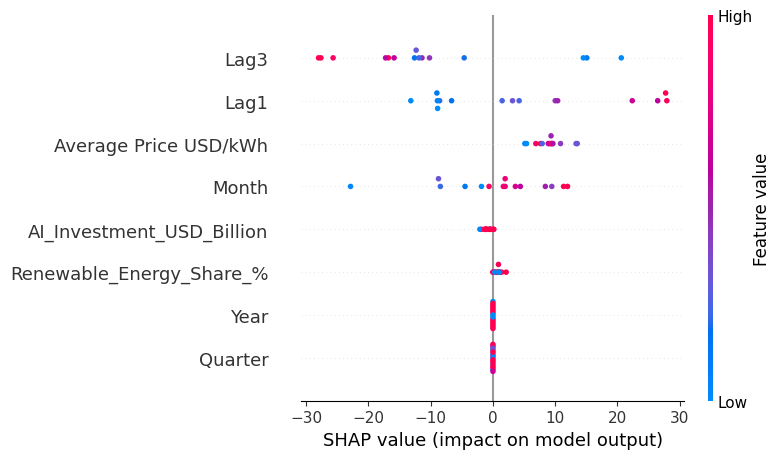

In [ ]:
X_test_xgb = test[features]
explainer=shap.Explainer(xgb)
values=explainer(X_test_xgb)
shap.summary_plot(values,X_test_xgb)

# Models Comparison

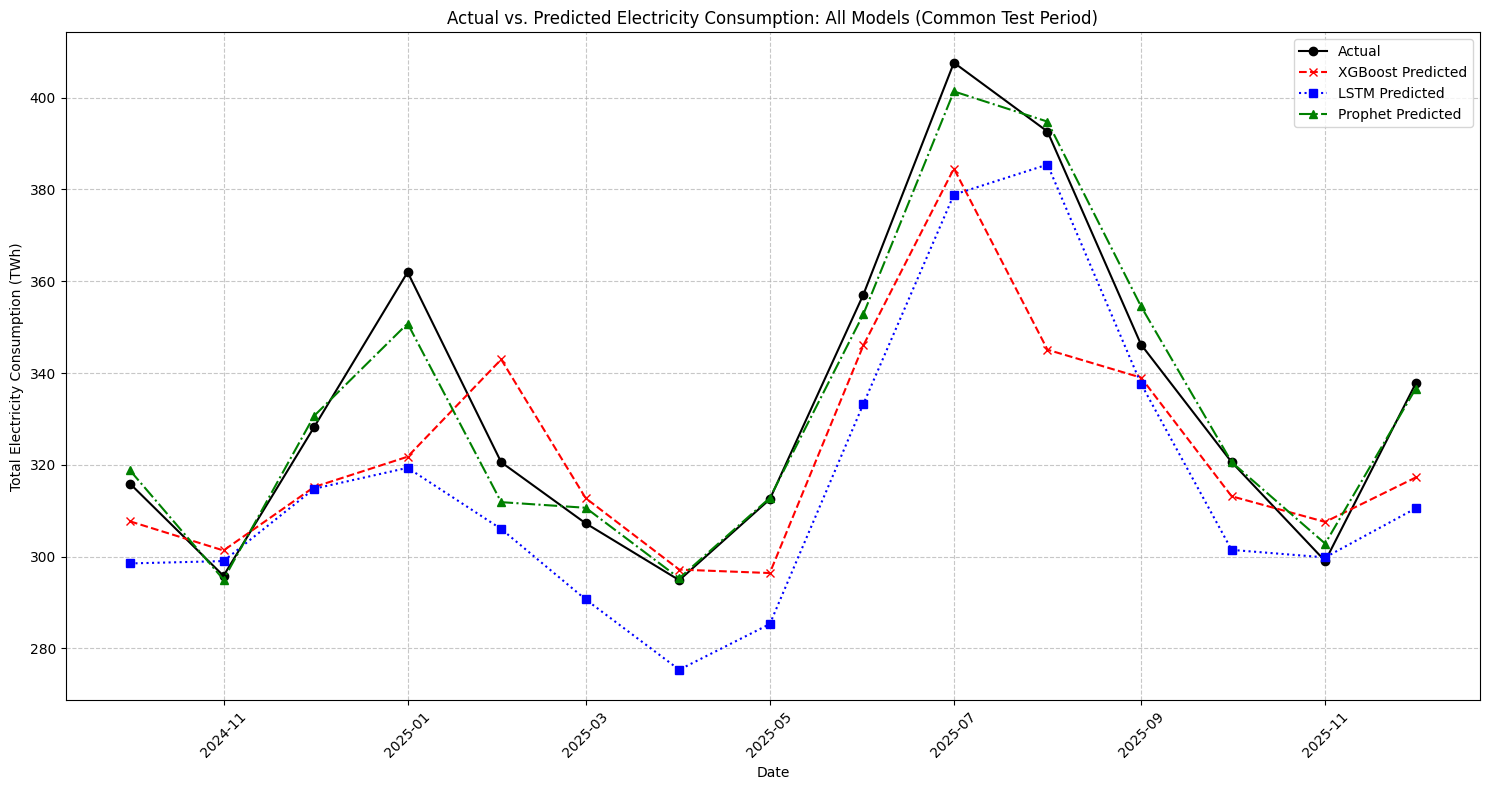

In [ ]:
# Aligning actual and predicted values for the common test period (15 months, defined by 'test' DataFrame)

# Actual values (common for all comparisons)
common_dates = test['Date'].reset_index(drop=True)
actual_common = test['Total Electricity_Consumption_TWh'].reset_index(drop=True)

# XGBoost predictions (taking the last 15 values to match 'test' DataFrame)
# 'pred' has 24 values, so we slice the last 15
pred_xgb_common = pred[-len(test):]

# LSTM predictions (taking the last 15 values to match 'test' DataFrame)
# 'prediction' has 21 values, so we slice the last 15
pred_lstm_common = prediction[-len(test):]

# Prophet predictions (y_pred is already aligned with the 'test' DataFrame)
pred_prophet_common = y_pred.reset_index(drop=True)

# Create a combined DataFrame for plotting
combined_forecast_df = pd.DataFrame({
    'Date': common_dates,
    'Actual': actual_common,
    'XGBoost_Predicted': pred_xgb_common,
    'LSTM_Predicted': pred_lstm_common,
    'Prophet_Predicted': pred_prophet_common
})

# Generate the combined line plot
plt.figure(figsize=(15, 8))
plt.plot(combined_forecast_df['Date'], combined_forecast_df['Actual'], label='Actual', marker='o', color='black')
plt.plot(combined_forecast_df['Date'], combined_forecast_df['XGBoost_Predicted'], label='XGBoost Predicted', linestyle='--', marker='x', color='red')
plt.plot(combined_forecast_df['Date'], combined_forecast_df['LSTM_Predicted'], label='LSTM Predicted', linestyle=':', marker='s', color='blue')
plt.plot(combined_forecast_df['Date'], combined_forecast_df['Prophet_Predicted'], label='Prophet Predicted', linestyle='-.', marker='^', color='green')

plt.title('Actual vs. Predicted Electricity Consumption: All Models (Common Test Period)')
plt.xlabel('Date')
plt.ylabel('Total Electricity Consumption (TWh)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Save Outputs

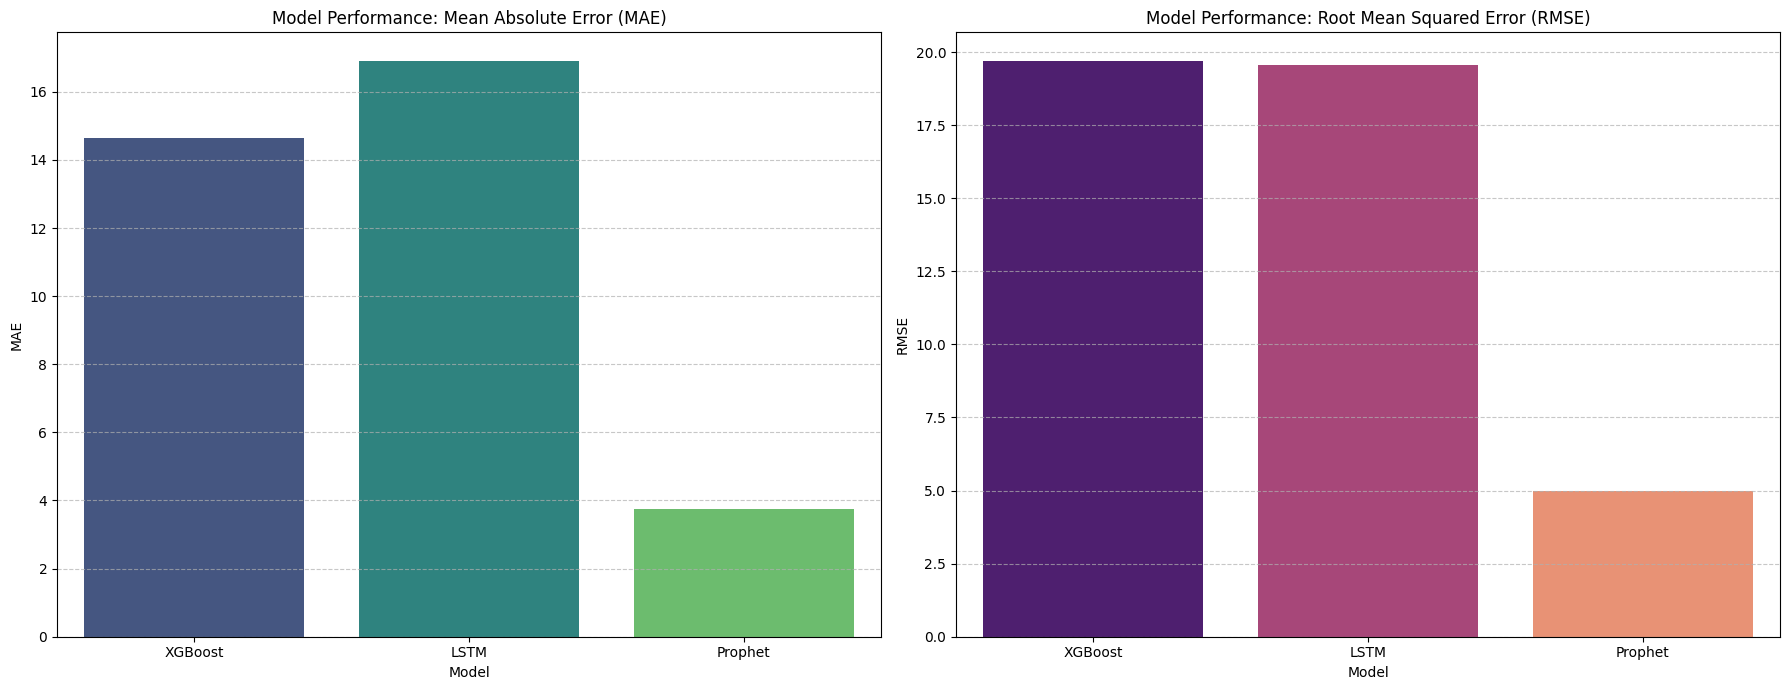

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the matplotlib figure and axes for two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart for MAE
sns.barplot(x='Model', y='MAE', data=comparison, ax=axes[0], palette='viridis')
axes[0].set_title('Model Performance: Mean Absolute Error (MAE)')
axes[0].set_ylabel('MAE')
axes[0].set_xlabel('Model')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Bar chart for RMSE
sns.barplot(x='Model', y='RMSE', data=comparison, ax=axes[1], palette='magma')
axes[1].set_title('Model Performance: Root Mean Squared Error (RMSE)')
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('Model')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
forecast.to_csv('forecast.csv',index=False)

In [ ]:
comparison.to_csv('model_performance.csv', index=False)

In [ ]:
display(comparison)

,Model,MAE,RMSE,MAPE,R2
0,XGBoost,14.650000,19.690000,-,0.688000
1,LSTM,16.900689,19.545289,4.999419,0.704303
2,Prophet,3.740000,5.000000,-,0.980000


**Summary on best suited model for forecasting**

Based on the evaluation metrics (MAE, RMSE, and R2 Score) from the comparison table, the Prophet model appears to be the best performing model among the three:

Prophet Model:

MAE: 3.74
RMSE: 5.00
R2 Score: 0.98
XGBoost Model:

MAE: 14.65
RMSE: 19.69
R2 Score: 0.688
LSTM Model:

MAE: 16.90
RMSE: 19.55
R2 Score: 0.704
Reasoning for Prophet being the best:

The Prophet model significantly outperforms both XGBoost and LSTM on this dataset, as evidenced by its much lower Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), and a substantially higher R2 Score. This indicates that Prophet's predictions are, on average, closer to the actual values and explain a much larger proportion of the variance in the electricity consumption data compared to the other two models.
